In [1]:
import sys
sys.path.insert(0, "/teamspace/studios/this_studio/PINNProof/PINNProof")  # change the path to your own path till PINNProof

In [25]:
import torch
import torch.nn as nn
from torchdiffeq import odeint_adjoint as odeint
import matplotlib.pyplot as plt

class SynchronousMachine(nn.Module):
    def __init__(self, 
                 D, P_m,
                 X_d_dash, X_q_dash,
                 X_d, X_q,
                 X_d_dash2, X_q_dash2,
                 H,
                 Rs, Re,
                 T_d_dash, T_q_dash,
                 T_d_dd, T_q_dd,
                 E_fd):
        """
        6th-order synchronous machine model whose state is:
         [δ, ω, E'_d, E'_q, E''_q, E''_d, V_t, θ_vs]
        """
        super().__init__()
        # mechanical & electrical params
        self.D = D
        self.P_m = P_m
        self.omega_B = 2 * torch.pi * 50.0
        self.H = H

        # reactances
        self.X_d_dash   = X_d_dash
        self.X_q_dash   = X_q_dash
        self.X_d        = X_d
        self.X_q        = X_q
        self.X_d_dash2  = X_d_dash2
        self.X_q_dash2  = X_q_dash2

        # resistances
        self.Rs = Rs
        self.Re = Re

        # time constants
        self.T_d_dash = T_d_dash
        self.T_q_dash = T_q_dash
        self.T_d_dd   = T_d_dd
        self.T_q_dd   = T_q_dd

        # field voltage
        self.E_fd = E_fd

        # precompute stator-impedance inverse
        Z = torch.tensor([[self.Rs,        -self.X_q_dash],
                          [ self.X_d_dash,  self.Rs    ]],
                         dtype=torch.float32)
        self.register_buffer('Z_inv', torch.linalg.inv(Z))

    def forward(self, t, y):
        """
        y: tensor of shape (8,) = [δ, ω, E'_d, E'_q, E''_q, E''_d, V_t, θ_vs]
        returns dy/dt of same shape
        """
        δ, ω, E_d_dash, E_q_dash, E_q_dd, E_d_dd, V_t, θ_vs = torch.unbind(y)

        # stator d/q voltages
        v_d = E_d_dash - V_t * torch.sin(δ - θ_vs)
        v_q = E_q_dash - V_t * torch.cos(δ - θ_vs)

        # currents
        I_d = self.Z_inv[0,0] * v_d + self.Z_inv[0,1] * v_q
        I_q = self.Z_inv[1,0] * v_d + self.Z_inv[1,1] * v_q

        # electrical power
        P_e = (E_d_dash * I_d
               + E_q_dash * I_q
               + (self.X_q_dash - self.X_d_dash) * I_d * I_q)

        # swing equations
        dδ_dt = ω
        dω_dt = (self.omega_B / (2*self.H)) * (self.P_m - P_e - self.D*ω)

        # transient emf dynamics (4th order)
        dE_d_dash = (1.0/self.T_q_dash) * (
            -E_d_dash + (self.X_q - self.X_q_dash)*I_q
        )
        dE_q_dash = (1.0/self.T_d_dash) * (
            -E_q_dash - (self.X_d - self.X_d_dash)*I_d + self.E_fd
        )

        # damper-winding (6th order)
        dE_q_dd = (1.0/self.T_d_dd) * (
            E_q_dash - E_q_dd + (self.X_d_dash - self.X_d_dash2)*I_d
        )
        dE_d_dd = (1.0/self.T_q_dd) * (
            E_d_dash - E_d_dd - (self.X_q_dash - self.X_q_dash2)*I_q
        )

        # V_t and θ_vs are exogenous => zero derivative
        dV_t    = torch.tensor(0.0, device=y.device)
        dθ_vs   = torch.tensor(0.0, device=y.device)

        return torch.stack([
            dδ_dt, dω_dt,
            dE_d_dash, dE_q_dash,
            dE_q_dd,   dE_d_dd,
            dV_t,      dθ_vs
        ])

    def interface(self, trajectory):
        """
        Given trajectory tensor shape (batch, time, 8):
         [δ, ω, E'_d, E'_q, E''_q, E''_d, V_t, θ_vs],
        compute and return (I_D, I_Q) each of shape (batch, time).
        """
        δ   = trajectory[..., 0]
        E_d = trajectory[..., 2]
        E_q = trajectory[..., 3]
        V_t = trajectory[..., 6]
        θ_vs= trajectory[..., 7]

        # d/q voltages
        v_d = E_d - V_t * torch.sin(δ - θ_vs)
        v_q = E_q - V_t * torch.cos(δ - θ_vs)

        # currents
        I_d = self.Z_inv[0,0]*v_d + self.Z_inv[0,1]*v_q
        I_q = self.Z_inv[1,0]*v_d + self.Z_inv[1,1]*v_q

        # park transform to D/Q frame
        cosρ = torch.cos(δ - torch.pi/2)
        sinρ = torch.sin(δ - torch.pi/2)
        I_D =  I_d * cosρ - I_q * sinρ
        I_Q =  I_d * sinρ + I_q * cosρ

        return I_D, I_Q

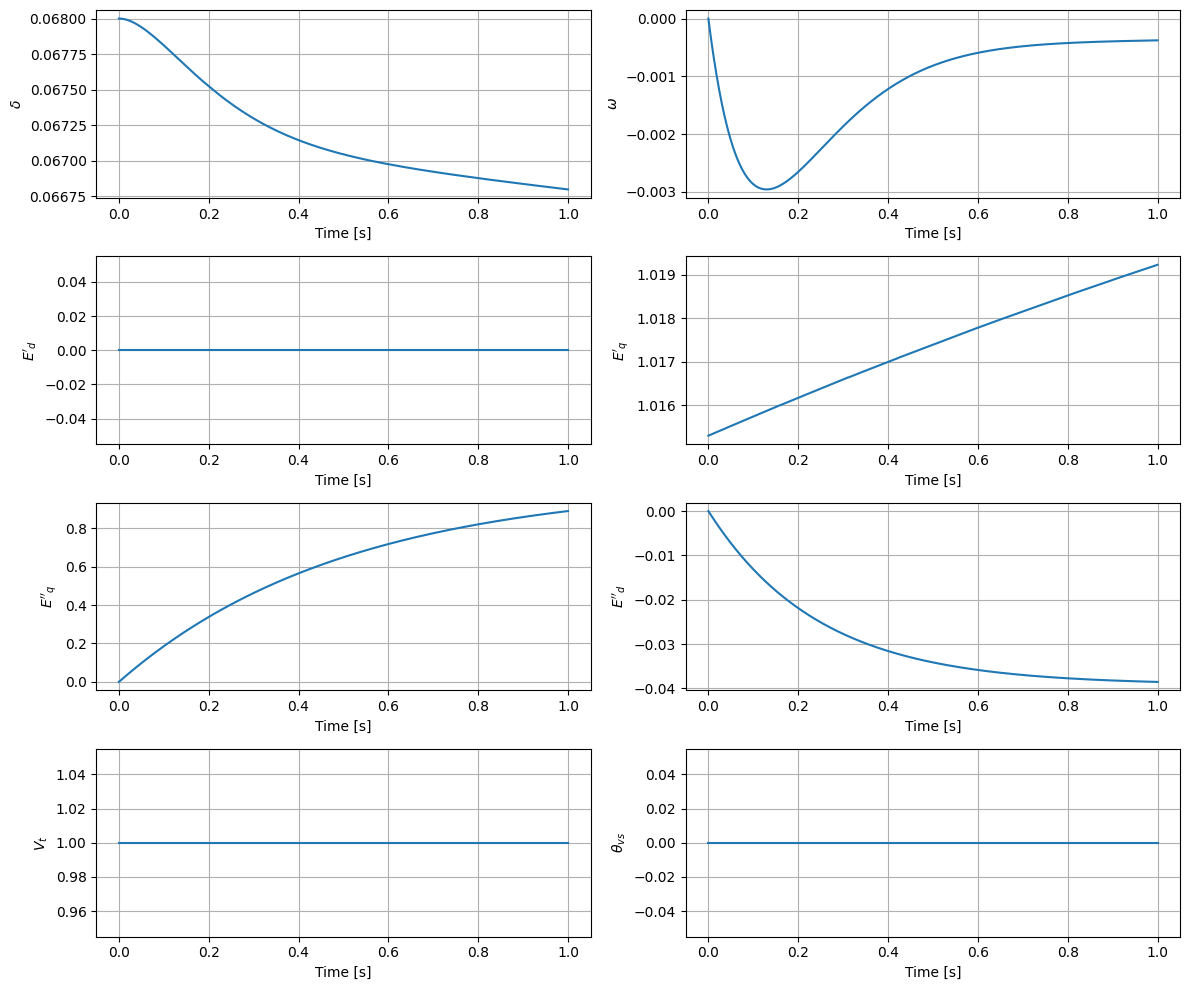

In [26]:
import torch
import matplotlib.pyplot as plt
from torchdiffeq import odeint
from src.solvers.solver import Solver           # your base classes
from src.solvers.ODE_conventional import ODE_conventional

# 1) Time‐vector and constant Vs profile
t_final, num_points = 1.0, 1000
t_tensor = torch.linspace(0., t_final, num_points)
Vs       = torch.ones(num_points)   # 1.0 pu
θs       = torch.zeros(num_points)  # 0 rad
# We'll embed Vs and θs directly into the state, so no extra stack needed here.

# 2) Machine parameters & instantiation
params = {
    'D'         : 2.364,
    'P_m'       : 0.71,
    'X_d_dash'  : 0.0608,
    'X_q_dash'  : 0.0969,
    'X_d'       : 0.146,
    'X_q'       : 0.0969,
    'X_d_dash2' : 0.03,
    'X_q_dash2' : 0.04,
    'H'         : 23.64,
    'Rs'        : 0.0,
    'Re'        : 0.0,
    'T_d_dash'  : 8.96,
    'T_q_dash'  : 0.31,
    'T_d_dd'    : 0.5,
    'T_q_dd'    : 0.25,
    'E_fd'      : 1.08
}
machine = SynchronousMachine(**params)

# 3) Wrap into your conventional ODE solver
#    forward: (t,y)->dy/dt, interface: (batch, time, 8)->(I_D,I_Q)
solver = ODE_conventional(machine.forward, machine.interface)

# 4) Build the 8-dim initial state [δ₀, ω₀, E′d₀, E′q₀, E″q₀, E″d₀, V_s₀, θ_s₀]
δ0       = 0.0680
ω0       = 0.0
E_d0     = 0.0
E_q0     = 1.0153
E_q_dd0  = 0.0
E_d_dd0  = 0.0
V_s0     = Vs[0].item()   # 1.0
θ_s0     = θs[0].item()   # 0.0
x0 = torch.tensor([δ0, ω0, E_d0, E_q0, E_q_dd0, E_d_dd0, V_s0, θ_s0],
                  dtype=torch.float32)

# 5) Solve!
t_sol, sol = solver.solve(x0, t_final, num_points)
# sol has shape (num_points, 8)

# 6) Extract rotor states
delta  = sol[:, 0]
omega  = sol[:, 1]
E_d    = sol[:, 2]
E_q    = sol[:, 3]

#import matplotlib.pyplot as plt

# assume t_sol (num_points,) and sol (num_points, 8) are from your solver
# sol[:,i] corresponds to:
labels = [
    r"$\delta$",
    r"$\omega$",
    r"$E'_d$",
    r"$E'_q$",
    r"$E''_q$",
    r"$E''_d$",
    r"$V_t$",
    r"$\theta_{vs}$"
]

fig, axs = plt.subplots(4, 2, figsize=(12, 10))
axs = axs.flatten()

for i in range(8):
    axs[i].plot(t_sol, sol[:, i].detach())
    axs[i].set_ylabel(labels[i])
    axs[i].set_xlabel("Time [s]")
    axs[i].grid(True)

plt.tight_layout()
plt.show()


In [27]:
# V_profile.shape

In [28]:
# Define initial‐condition ranges for every state in [δ, ω, E′d, E′q, E″q, E″d, V_t, θ_vs]
ic_ranges = {
    'delta'     : (-2,  2),   # rotor angle [rad]
    'omega'     : (-1, 1),   # speed deviation [pu]
    'E_d_dash'  : (0.0,   0.0),   # transient d‐axis emf fixed
    'E_q_dash'  : (1.0,   1.0),   # transient q‐axis emf fixed
    'E_q_dd'    : (0.0,   0.0),   # subtransient q‐axis emf fixed
    'E_d_dd'    : (1.0,   1.0),   # subtransient d‐axis emf fixed
    'V_t'       : (0.95,   1.05),   # terminal voltage magnitude [pu]
    'theta_vs'  : (-0.3,  0.3),   # terminal voltage angle [rad]
}
# - {name: theta, range: [-2, 2], iterations: 7}
# - {name: omega, range: [-1, 1], iterations: 7}
# - {name: E_d_dash, range: [0], iterations: 1}
# - {name: E_q_dash, range: [0.9, 1.1], iterations: 5}
# - {name: E_d_dash_dash, range: [0], iterations: 1}
# - {name: E_q_dash_dash, range: [1], iterations: 1}
# - {name: Vs, range: [0.95,1.05], iterations: 3}
# - {name: theta_vs, range: [-0.3,0.3], iterations: 4}

t, data, ics = solver.generate_dataset(
    ic_ranges=ic_ranges,
    num_ic=100,
    t_final=t_final,
    num_points=num_points
)


In [29]:
I_D, I_Q = solver.interface(data)


In [30]:
import os
os.getcwd()
# Change to a new directory  
os.chdir("./PINNProof/PINNProof/")  
print("After Changing:", os.getcwd())
from pretrained_models.architectures import Network


FileNotFoundError: [Errno 2] No such file or directory: './PINNProof/PINNProof/'

In [8]:
model=Network(input_size=9, hidden_size=64, output_size=6, num_layers=3,activation="tanh")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "examples/pretrained_models/SM6_LBFGS_seed7.pth"
model_data = torch.load(model_path, weights_only=True, map_location=device)
# Check if model_data contains the key 'model_state_dict'
if isinstance(model_data, dict) and 'model_state_dict' in model_data:
    state_dict = model_data['model_state_dict']
else:
    state_dict = model_data
    print(state_dict)
    print("Model state keys:", state_dict.keys())
    print("Expected model keys:", model.state_dict().keys())
model.load_state_dict(state_dict)

<All keys matched successfully>

# TESTING OTHER FUNCTIONS

In [ ]:
from src.verification.utils import *

# For Petros' method, this one needs to be implemented after making necessary changes
ic_ranges_tensor = torch.tensor(list(ic_ranges.values()))
bounds_for_sampling = list(map(tuple, ic_ranges_tensor.tolist()))
samples = sampling_domain(bounds_for_sampling, 5)
print(samples.shape)

(390625, 8)


In [ ]:
# Indrajit's method, simplified a bit (only used for testing that samples can be generated)
bounds_for_sampling = ic_ranges.copy()
bounds_for_sampling['t'] = (0.0, t_final)  # add the time bounds for all-in-one sampling before the lipschitz calc
samples = torch.tensor(generate_samples(bounds_for_sampling, 1500, 'random'))
print(samples.shape)

torch.Size([1500, 9])


/tmp/ipykernel_22232/2108360267.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:275.)
  samples = torch.tensor(generate_samples(bounds_for_sampling, 1500, 'random'))


In [27]:
from src.verification.verifier import verifier

example_verifier = verifier(model, model, ic_ranges)  # note that ic_ranges does not include 't'

ModuleNotFoundError: No module named 'external_lib'

In [13]:
# note that bounds_for_sampling contains 't' added to the end of ic_ranges
print("ic_ranges: ")
print(ic_ranges)
print("\nbounds_for_sampling: ")
print(bounds_for_sampling)

ic_ranges: 
{'delta': (-0.1, 0.1), 'omega': (-0.2, 0.2), 'E_d_dash': (0.0, 0.0), 'E_q_dash': (1.0, 1.0), 'E_q_dd': (0.0, 0.0), 'E_d_dd': (0.0, 0.0), 'V_t': (0.9, 1.1), 'theta_vs': (-0.1, 0.1)}

bounds_for_sampling: 
{'delta': (-0.1, 0.1), 'omega': (-0.2, 0.2), 'E_d_dash': (0.0, 0.0), 'E_q_dash': (1.0, 1.0), 'E_q_dd': (0.0, 0.0), 'E_d_dd': (0.0, 0.0), 'V_t': (0.9, 1.1), 'theta_vs': (-0.1, 0.1), 't': (0.0, 1.0)}


In [14]:
# Find the result of gradient attack on model vs model
G = example_verifier.gradient_attack(model, model, bounds_for_sampling, num_steps=100, learning_rate=0.01, num_restarts=10)
print(G)

NameError: name 'example_verifier' is not defined

In [29]:
# Find the result of ECP on model vs model
E = example_verifier.every_call_counts(model, model, bounds_for_sampling, num_steps=100)
print(E)

NameError: name 'example_verifier' is not defined

In [11]:
from src.solvers.solver_nn import Solver_NN
import numpy as np

In [12]:
sample_solver_nn = Solver_NN(func=machine.forward, n_control=2, n_states=6, model=model)  # assuming states=6 for SM6, hence control=2 since number of inputs is 9

In [13]:
t, Y = sample_solver_nn.solve(ini_cond=[0.2, 0.3, -0.4, 0.1, 0.0, 0.6, 0.8, -0.18], t_final=2.0, num_points=100)  # random sample initial conditions, 8 in number excluding time variable
print(t.shape)
print(Y.shape)

(100,)
(100, 6)


In [14]:
bounds_for_sampling

{'delta': (-2, 2),
 'omega': (-1, 1),
 'E_d_dash': (0.0, 0.0),
 'E_q_dash': (1.0, 1.0),
 'E_q_dd': (0.0, 0.0),
 'E_d_dd': (1.0, 1.0),
 'V_t': (0.95, 1.05),
 'theta_vs': (-0.3, 0.3),
 't': (0.0, 1.0)}

In [43]:
# Find the residuals from this nn_solver object
R = sample_solver_nn.compute_residuals(bounds=bounds_for_sampling, num_trajectories=17, num_points=130)
print(R.shape)

torch.Size([17, 130, 6])


In [47]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def _edges_from_centers(x):
    """Compute bin edges from sorted centers (non-uniform OK)."""
    x = np.asarray(x)
    if x.size == 1:
        # single row: make a small band around it
        return np.array([x[0]-0.5, x[0]+0.5])
    mid = 0.5*(x[:-1] + x[1:])
    first = x[0] - (mid[0] - x[0])
    last  = x[-1] + (x[-1] - mid[-1])
    return np.concatenate(([first], mid, [last]))

def _time_edges(t0, t1, T):
    t = np.linspace(t0, t1, T)
    if T == 1:
        return np.array([t0-0.5, t1+0.5])
    dt = np.diff(t)
    left  = t[0] - dt[0]/2
    right = t[-1] + dt[-1]/2
    mids  = 0.5*(t[:-1] + t[1:])
    return np.concatenate(([left], mids, [right]))

def plot_residual_heatmaps_by_state_y(
    R,                    # (N, T, S) tensor/array
    y0s,                  # (N, 8) ICs; first 6 are the states
    t_bounds,             # (t0, t1)
    state_labels=None,    # list of S labels
    log_scale=True,
    eps=1e-12
):
    # to numpy
    if isinstance(R, torch.Tensor): R = R.detach().cpu().numpy()
    if isinstance(y0s, torch.Tensor): y0s = y0s.detach().cpu().numpy()
    N, T, S = R.shape
    assert y0s.shape[0] == N, "y0s must have N rows to match R."

    if state_labels is None:
        state_labels = [r"$\delta$", r"$\omega$", r"$E'_d$", r"$E'_q$", r"$E''_q$", r"$E''_d$"]

    t0, t1 = t_bounds
    t_edges = _time_edges(t0, t1, T)

    # choose magnitude (log or linear)
    if log_scale:
        Rplot = np.log10(np.abs(R) + eps)
        cbar_label = r"$\log_{10}(|\mathrm{residual}|)$"
    else:
        Rplot = R
        cbar_label = "residual"

    for s in range(S):
        # y-axis = IC of state s
        yvals = y0s[:, s]
        order = np.argsort(yvals)
        y_sorted = yvals[order]
        Z = Rplot[order, :, s]                      # (N, T)

        y_edges = _edges_from_centers(y_sorted)     # (N+1,)

        plt.figure(figsize=(8, 4))
        # pcolormesh expects Z shape (len(y_edges)-1, len(t_edges)-1)
        plt.pcolormesh(t_edges, y_edges, Z, shading='auto')
        plt.colorbar(label=cbar_label)
        plt.xlabel("Time [s]")
        plt.ylabel(f"IC of {state_labels[s]}")
        plt.title(f"Residual heatmap vs time (y = {state_labels[s]})")
        plt.tight_layout()
        plt.show()


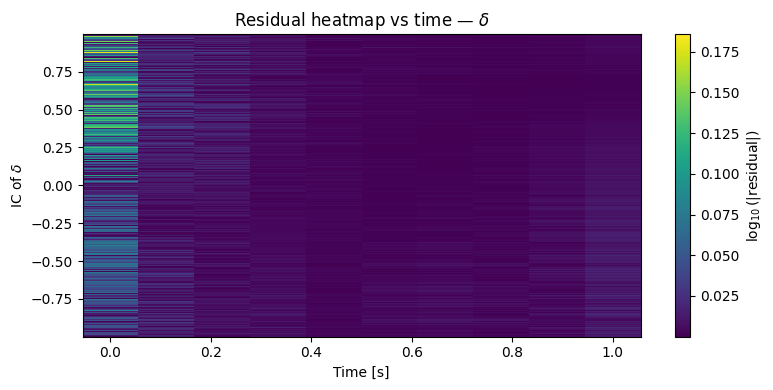

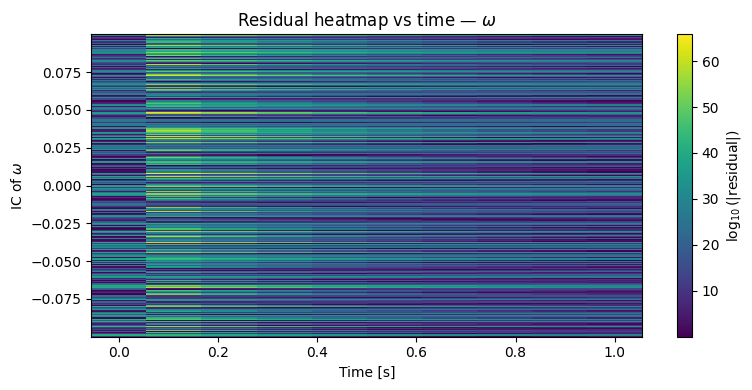

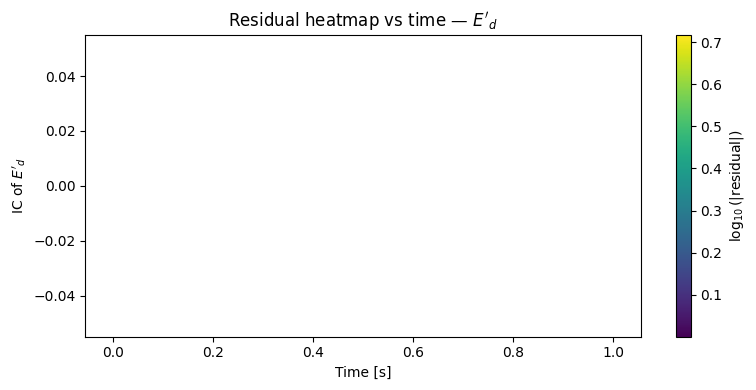

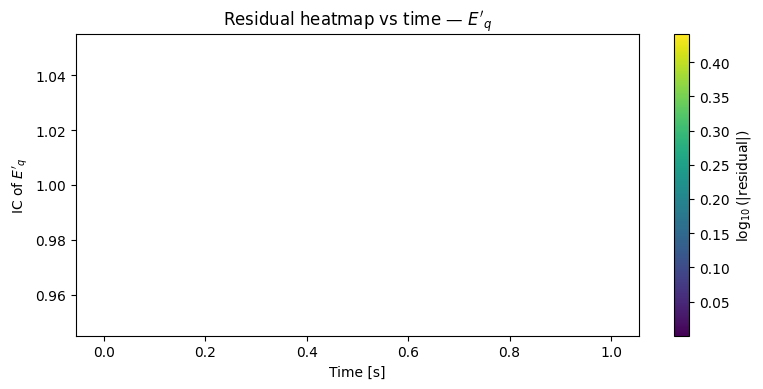

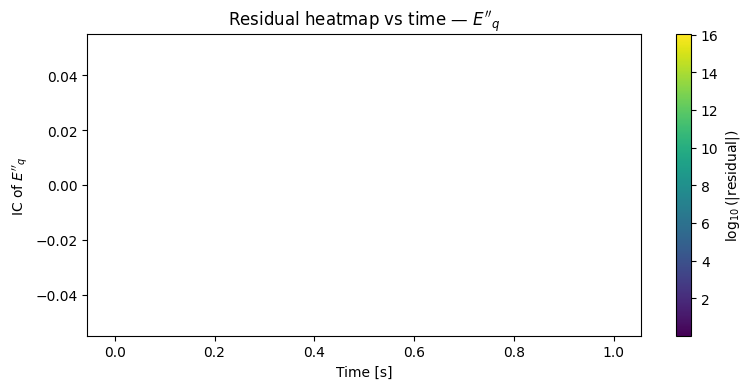

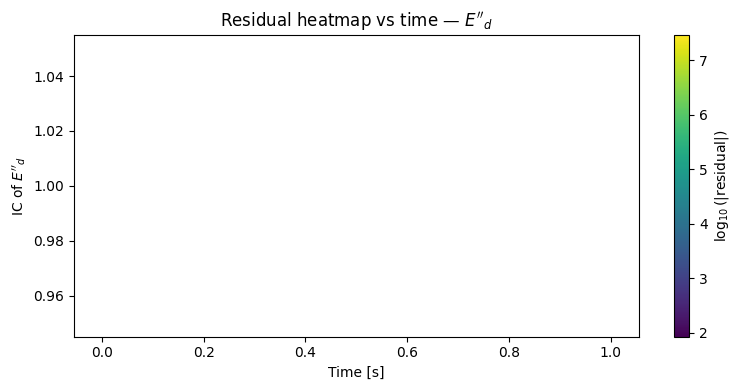

In [33]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
from pathlib import Path

def pinn_residual_heatmaps_by_state_y(
    solver,                    # your Solver_NN (needs .model, .func, .n_states, .generate_batched_samples)
    bounds,                    # dict with keys for 8 states + 't'
    num_trajectories: int,
    num_points: int,
    *,
    outputs_are_slopes: bool = False,
    state_labels = (r"$\delta$", r"$\omega$", r"$E'_d$", r"$E'_q$", r"$E''_q$", r"$E''_d$"),
    log10: bool = True,
    eps: float = 1e-12,
    save_dir: str | None = None,
):
    """
    Computes residuals r = dy/dt - f(t,y) and plots one heatmap per state:
      x-axis: time, y-axis: IC value of the SAME state, color: residual magnitude.
    Returns (R, y0s): residual tensor (N,T,S) and the IC matrix (N,8).
    """
    def _edges_from_centers(x):
        x = np.asarray(x)
        if x.size == 1:
            return np.array([x[0] - 0.5, x[0] + 0.5])
        mid = 0.5 * (x[:-1] + x[1:])
        first = x[0] - (mid[0] - x[0])
        last  = x[-1] + (x[-1] - mid[-1])
        return np.concatenate(([first], mid, [last]))

    def _time_edges(t0, t1, T):
        t = np.linspace(t0, t1, T)
        if T == 1:
            return np.array([t0 - 0.5, t1 + 0.5])
        mids = 0.5 * (t[:-1] + t[1:])
        left  = t[0]  - (mids[0] - t[0])
        right = t[-1] + (t[-1] - mids[-1])
        return np.concatenate(([left], mids, [right]))

    # ------------------ sample ICs/time exactly once ------------------
    var_names = [k for k in bounds.keys() if k != 't']  # keep your order
    y0s, t_grid = solver.generate_batched_samples(bounds, var_names, num_trajectories, num_points)
    # Model device for autograd; func (machine.forward) will be run on CPU
    model_device = next(solver.model.parameters()).device

    y0s = y0s.to(model_device)
    t_grid = t_grid.to(model_device)

    # Flatten time (enable grad)
    t_vec = t_grid.reshape(-1, 1).clone().detach().requires_grad_(True)     # (N*T,1)
    # Repeat ICs per time step
    y0s_vec = y0s.repeat_interleave(num_points, dim=0)                       # (N*T, 8)

    # Split states/controls
    S = solver.n_states
    y0_states_vec = y0s_vec[:, :S]                                           # (N*T, 6)
    y0_ctrl_vec   = y0s_vec[:, S:] if y0s_vec.shape[1] > S else None         # (N*T, 2) or None

    # ------------------ forward PINN ------------------
    # Model input matches your solve(): [t, y0(8)]
    model_input = torch.cat([t_vec, y0s_vec], dim=1)                         # (N*T, 9)
    solver.model.eval()
    net_out = solver.model(model_input)                                      # (N*T, 6)

    # Reconstruct y(t)
    if outputs_are_slopes:
        y_hat = y0_states_vec + net_out * t_vec                              # slopes -> states
    else:
        y_hat = net_out                                                      # states directly

    # ------------------ dy/dt (per state) ------------------
    grads = []
    for k in range(S):
        gk = torch.autograd.grad(
            outputs=y_hat[:, k:k+1],
            inputs=t_vec,
            grad_outputs=torch.ones_like(y_hat[:, k:k+1]),
            create_graph=True,
            retain_graph=True#(k < S - 1)
        )[0]                                                                 # (N*T,1)
        grads.append(gk)
    dy_dt = torch.cat(grads, dim=1)                                          # (N*T,6)

    # ------------------ RHS f(t,y) on CPU (robust to device mix) ------------------
    # Detach y and move to CPU for machine.forward(t,y)
    y_hat_cpu   = y_hat.detach().cpu()
    y0_ctrl_cpu = y0_ctrl_vec.detach().cpu() if y0_ctrl_vec is not None else None
    y_full_cpu  = torch.cat([y_hat_cpu, y0_ctrl_cpu], dim=1) if y0_ctrl_cpu is not None else y_hat_cpu
    t_cpu       = t_vec.detach().cpu().squeeze(-1)

    f_list = []
    with torch.no_grad():
        for i in range(y_full_cpu.shape[0]):
            fi = solver.func(t_cpu[i], y_full_cpu[i])                        # (8,)
            f_list.append(fi)
    f_full = torch.stack(f_list, dim=0).to(dy_dt.dtype)                      # (N*T,8) on CPU
    f_val  = f_full[:, :S].to(model_device)                                  # back to model device

    # ------------------ residuals and reshape ------------------
    R = (dy_dt - f_val).view(num_trajectories, num_points, S)                # (N,T,6)
    R_np   = R.detach().cpu().numpy()
    y0s_np = y0s.detach().cpu().numpy()

    # ------------------ plot heatmaps ------------------
    t0, t1 = bounds['t']
    t_edges = _time_edges(t0, t1, num_points)

    if log10:
        Z_title = r"$\log_{10}(|\mathrm{residual}|)$"
    else:
        Z_title = "residual"

    if save_dir is not None:
        Path(save_dir).mkdir(parents=True, exist_ok=True)

    for s in range(S):
        # y-axis = IC of state s
        yvals   = y0s_np[:, s]                       # (N,)
        order   = np.argsort(yvals)
        y_sorted= yvals[order]
        Z       = R_np[order, :, s]
        Zplot =np.abs(Z)
        # Zplot   = np.log10(np.abs(Z) + eps) if log10 else Z
        y_edges = _edges_from_centers(y_sorted)

        plt.figure(figsize=(8, 4))
        plt.pcolormesh(t_edges, y_edges, Zplot, shading='auto')
        plt.colorbar(label=Z_title)
        plt.xlabel("Time [s]")
        plt.ylabel(f"IC of {state_labels[s]}")
        plt.title(f"Residual heatmap vs time — {state_labels[s]}")
        plt.tight_layout()
        if save_dir:
            plt.savefig(os.path.join(save_dir, f"residual_heatmap_{s}.png"), dpi=200)
        plt.show()

    return R, y0s_np
bounds_for_sampling= {
    't':(0,1),
    'delta'     : (-1,  1),   # rotor angle [rad]
    'omega'     : (-0.1, 0.1),   # speed deviation [pu]
    'E_d_dash'  : (0.0,   0.0),   # transient d‐axis emf fixed
    'E_q_dash'  : (1.0,   1.0),   # transient q‐axis emf fixed
    'E_q_dd'    : (0.0,   0.0),   # subtransient q‐axis emf fixed
    'E_d_dd'    : (1.0,   1.0),   # subtransient d‐axis emf fixed
    'V_t'       : (0.95,   1.05),   # terminal voltage magnitude [pu]
    'theta_vs'  : (-0.3,  0.3),   # terminal voltage angle [rad]
}
R, y0s = pinn_residual_heatmaps_by_state_y(
    solver=sample_solver_nn,
    bounds=bounds_for_sampling,       # includes 't': (0.0, t_final)
    num_trajectories=1000,
    num_points=10,
    outputs_are_slopes=False,         # set True if your net outputs slopes
    save_dir=None                     # or "figs/residuals"
)


In [22]:
R

tensor([[[-4.7836e-02,  1.9276e+01, -8.5048e-03,  8.1995e-02, -2.5329e+00,
           4.0951e+00],
         [ 4.7700e-03,  3.8311e+00,  2.1552e-02, -1.1811e-02, -2.2375e+00,
           4.1112e+00],
         [ 8.8825e-03,  5.7482e+00,  3.6975e-02, -2.3578e-02, -2.2304e+00,
           4.1641e+00],
         ...,
         [-5.3120e-03,  1.2335e+01,  1.5755e-01, -2.4596e-02, -2.2094e+00,
           4.2655e+00],
         [-1.0127e-02,  1.3280e+01,  1.7305e-01, -2.6973e-02, -2.2010e+00,
           4.2633e+00],
         [-1.5833e-02,  1.4157e+01,  1.8539e-01, -3.0296e-02, -2.1934e+00,
           4.2571e+00]],

        [[-1.8701e-01,  9.9225e+00,  1.7385e-01, -5.8678e-02, -9.9446e+00,
           5.6383e+00],
         [ 2.9968e-03,  3.4015e+01,  2.5581e-01, -9.7331e-02, -2.8740e+00,
           5.0586e+00],
         [ 2.1718e-02,  3.2373e+01,  3.0576e-01, -7.6406e-02, -2.3602e+00,
           4.8809e+00],
         ...,
         [ 1.6329e-03,  2.7134e+01,  4.6842e-01, -5.7033e-02, -2.1292e+00,
    